Running: {'optimizer_name': 'adam', 'init_type': 'he', 'regularizer_type': None, 'use_bn': False, 'dropout_rate': 0.0}
Running: {'optimizer_name': 'sgd', 'init_type': 'he', 'regularizer_type': None, 'use_bn': True, 'dropout_rate': 0.0}
Running: {'optimizer_name': 'adam', 'init_type': 'he', 'regularizer_type': None, 'use_bn': True, 'dropout_rate': 0.0}
Running: {'optimizer_name': 'rmsprop', 'init_type': 'he', 'regularizer_type': None, 'use_bn': True, 'dropout_rate': 0.0}
Running: {'optimizer_name': 'adam', 'init_type': 'he', 'regularizer_type': None, 'use_bn': True, 'dropout_rate': 0.0}
Running: {'optimizer_name': 'adam', 'init_type': 'xavier', 'regularizer_type': None, 'use_bn': True, 'dropout_rate': 0.0}
Running: {'optimizer_name': 'adam', 'init_type': 'he', 'regularizer_type': 'l1', 'use_bn': True, 'dropout_rate': 0.0}
Running: {'optimizer_name': 'adam', 'init_type': 'he', 'regularizer_type': 'l2', 'use_bn': True, 'dropout_rate': 0.0}
Running: {'optimizer_name': 'adam', 'init_type': 

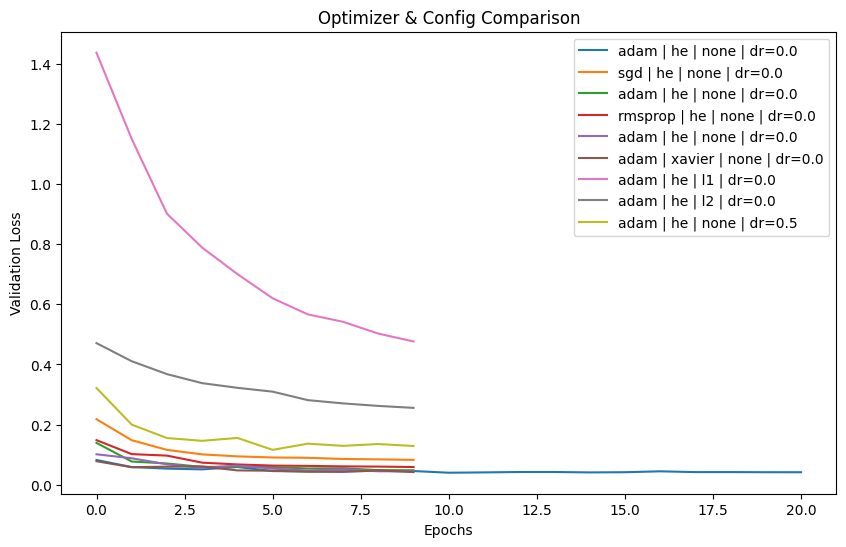


=== FINAL RESULTS ===
                                              config          RMSE  \
0  {'optimizer_name': 'adam', 'init_type': 'he', ...  1.327742e+06   
5  {'optimizer_name': 'adam', 'init_type': 'xavie...  1.807274e+06   
6  {'optimizer_name': 'adam', 'init_type': 'he', ...  2.021049e+06   
7  {'optimizer_name': 'adam', 'init_type': 'he', ...  2.093072e+06   
4  {'optimizer_name': 'adam', 'init_type': 'he', ...  2.107420e+06   
2  {'optimizer_name': 'adam', 'init_type': 'he', ...  2.446374e+06   
3  {'optimizer_name': 'rmsprop', 'init_type': 'he...  2.544719e+06   
1  {'optimizer_name': 'sgd', 'init_type': 'he', '...  2.974199e+06   
8  {'optimizer_name': 'adam', 'init_type': 'he', ...  3.617217e+06   

            MAE        R2  
0  9.513154e+05  0.960269  
5  1.406787e+06  0.926387  
6  1.525444e+06  0.907943  
7  1.622179e+06  0.901264  
4  1.601506e+06  0.899906  
2  1.849105e+06  0.865119  
3  1.938235e+06  0.854056  
1  2.239647e+06  0.800637  
8  2.444441e+06  0.70511

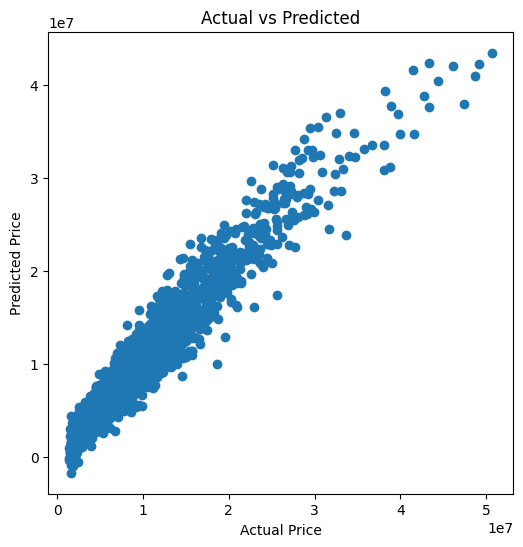

Actual: 4,974,421 | Predicted: 3,502,515
Actual: 5,558,515 | Predicted: 6,089,594
Actual: 14,959,629 | Predicted: 12,431,349
Actual: 1,562,114 | Predicted: 1,023,746
Actual: 3,745,098 | Predicted: 3,627,725


In [1]:
# =========================
# 1. IMPORTS
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.regularizers import l1, l2
from tensorflow.keras.initializers import GlorotUniform, HeNormal
from tensorflow.keras.optimizers import SGD, Adam, RMSprop
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping


# =========================
# 2. LOAD DATA
# =========================
df = pd.read_csv("house_price_dataset_india_12k.csv")
df.columns = df.columns.str.strip()
df = df.drop(columns=["House_ID", "Price_per_sqft_INR"], errors="ignore")

X = df.drop("Market_Price_INR", axis=1)
y = df["Market_Price_INR"]


# =========================
# 3. PREPROCESSING
# =========================
categorical_nominal = ["City", "Furnishing"]
categorical_ordinal = ["Locality_Tier"]

locality_map = {"Budget": 0, "Mid": 1, "Premium": 2}
X["Locality_Tier"] = X["Locality_Tier"].map(locality_map)

numerical_cols = [col for col in X.columns if col not in categorical_nominal + categorical_ordinal]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_nominal)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

# Scale target
y_scaler = StandardScaler()
y_train = y_scaler.fit_transform(y_train.values.reshape(-1,1))
y_test = y_scaler.transform(y_test.values.reshape(-1,1))


# =========================
# 4. MODEL BUILDER
# =========================
def build_model(optimizer_name="adam", init_type="he", regularizer_type=None,
                use_bn=True, dropout_rate=0.0):

    initializer = HeNormal() if init_type == "he" else GlorotUniform()

    reg = None
    if regularizer_type == "l1":
        reg = l1(0.001)
    elif regularizer_type == "l2":
        reg = l2(0.001)

    model = Sequential()
    model.add(Input(shape=(X_train.shape[1],)))

    # Layer 1
    model.add(Dense(128, kernel_initializer=initializer, kernel_regularizer=reg))
    if use_bn:
        model.add(BatchNormalization())
    model.add(tf.keras.layers.ReLU())
    if dropout_rate > 0:
        model.add(Dropout(dropout_rate))

    # Layer 2
    model.add(Dense(64, kernel_initializer=initializer, kernel_regularizer=reg))
    if use_bn:
        model.add(BatchNormalization())
    model.add(tf.keras.layers.ReLU())
    if dropout_rate > 0:
        model.add(Dropout(dropout_rate))

    # Layer 3
    model.add(Dense(32, kernel_initializer=initializer))
    model.add(tf.keras.layers.ReLU())

    model.add(Dense(1, activation='linear'))

    if optimizer_name == "sgd":
        optimizer = SGD(learning_rate=0.001, momentum=0.9)
    elif optimizer_name == "rmsprop":
        optimizer = RMSprop(learning_rate=0.0005)
    else:
        optimizer = Adam(learning_rate=0.001)

    model.compile(optimizer=optimizer, loss="mse", metrics=["mae"])

    return model


# =========================
# 5. CALLBACKS
# =========================
early_stop = EarlyStopping(patience=10, restore_best_weights=True)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5
)


# =========================
# 6. TRAIN FUNCTION
# =========================
def train_model(config):
    model = build_model(**config)

    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=50,
        batch_size=32,
        verbose=0,
        callbacks=[early_stop, lr_scheduler]
    )

    return model, history


# =========================
# 7. EXPERIMENT MATRIX (CLEAN)
# =========================
experiments = [
    # Baseline (VERY IMPORTANT)
    {"optimizer_name": "adam", "init_type": "he", "regularizer_type": None, "use_bn": False, "dropout_rate": 0.0},

    # Optimizers
    {"optimizer_name": "sgd", "init_type": "he", "regularizer_type": None, "use_bn": True, "dropout_rate": 0.0},
    {"optimizer_name": "adam", "init_type": "he", "regularizer_type": None, "use_bn": True, "dropout_rate": 0.0},
    {"optimizer_name": "rmsprop", "init_type": "he", "regularizer_type": None, "use_bn": True, "dropout_rate": 0.0},

    # Initialization
    {"optimizer_name": "adam", "init_type": "he", "regularizer_type": None, "use_bn": True, "dropout_rate": 0.0},
    {"optimizer_name": "adam", "init_type": "xavier", "regularizer_type": None, "use_bn": True, "dropout_rate": 0.0},

    # Regularization
    {"optimizer_name": "adam", "init_type": "he", "regularizer_type": "l1", "use_bn": True, "dropout_rate": 0.0},
    {"optimizer_name": "adam", "init_type": "he", "regularizer_type": "l2", "use_bn": True, "dropout_rate": 0.0},
    {"optimizer_name": "adam", "init_type": "he", "regularizer_type": None, "use_bn": True, "dropout_rate": 0.5},
]


# =========================
# 8. RUN EXPERIMENTS
# =========================
results = []

plt.figure(figsize=(10,6))

for config in experiments:
    print("Running:", config)

    model, history = train_model(config)

    y_pred_scaled = model.predict(X_test, verbose=0)
    y_pred = y_scaler.inverse_transform(y_pred_scaled)
    y_test_actual = y_scaler.inverse_transform(y_test)

    rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))
    mae = mean_absolute_error(y_test_actual, y_pred)
    r2 = r2_score(y_test_actual, y_pred)

    results.append({
        "config": config,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })

    label = f"{config['optimizer_name']} | {config['init_type']} | {config['regularizer_type'] or 'none'} | dr={config['dropout_rate']}"
    plt.plot(history.history["val_loss"], label=label)

plt.title("Optimizer & Config Comparison")
plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.legend()
plt.show()


# =========================
# 9. RESULTS TABLE
# =========================
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="RMSE")

print("\n=== FINAL RESULTS ===")
print(results_df)


# =========================
# 10. BEST MODEL
# =========================
best_config = results_df.iloc[0]["config"]
print("\nBest Config:", best_config)

best_model, _ = train_model(best_config)


# =========================
# 11. FINAL EVALUATION
# =========================
y_pred_scaled = best_model.predict(X_test, verbose=0)
y_pred = y_scaler.inverse_transform(y_pred_scaled)
y_test_actual = y_scaler.inverse_transform(y_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test_actual, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()


# =========================
# 12. SAMPLE PREDICTIONS
# =========================
for i in range(5):
    print(f"Actual: {y_test_actual[i][0]:,.0f} | Predicted: {y_pred[i][0]:,.0f}")
